In [1]:
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Chargement des données
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Séparation : 70% Train, 15% Validation, 15% Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

# 3. Normalisation (Standardisation)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 4. Conversion en tenseurs PyTorch
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print(f"Dimensions Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Dimensions Train: torch.Size([397, 30]), Val: torch.Size([86, 30]), Test: torch.Size([86, 30])


Avec nn.Sequential

In [2]:
input_dim = X_train.shape[1] # 30 features

mlp_sequential = nn.Sequential(
    nn.Linear(input_dim, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
    # Pas de Sigmoid ici car nous utiliserons BCEWithLogitsLoss plus tard
)

Avec une classe personnalisée (Héritage de nn.Module)

In [3]:
class CustomMLP(nn.Module):
    def __init__(self, input_dim):
        super(CustomMLP, self).__init__()
        self.layer1 = nn.Linear(input_dim, 16)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(16, 8)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(8, 1)

    def forward(self, x):
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.output(x)
        return x

mlp_custom = CustomMLP(input_dim)

Stratégies d'initialisation des poids

In [4]:
def init_weights(m, strategy="xavier"):
    if isinstance(m, nn.Linear):
        if strategy == "gaussienne":
            nn.init.normal_(m.weight, mean=0.0, std=0.01) # Gaussienne
        elif strategy == "constante":
            nn.init.constant_(m.weight, 0.1) # Constante
        elif strategy == "xavier":
            nn.init.xavier_uniform_(m.weight) # Xavier
        nn.init.zeros_(m.bias)

# Exemple d'application :
mlp_custom.apply(lambda m: init_weights(m, strategy="xavier"))

CustomMLP(
  (layer1): Linear(in_features=30, out_features=16, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=8, out_features=1, bias=True)
)

Étape 1 : La gestion du CPU / GPU

In [5]:
# 1. Détection de l'appareil (Device)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilisé pour l'entraînement : {device}")

# 2. Transfert du modèle sur l'appareil
# (Nous utiliserons mlp_custom, la version orientée objet que tu as initialisée)
model = mlp_custom.to(device)

# 3. Transfert des données sur l'appareil
X_train, y_train = X_train.to(device), y_train.to(device)
X_val, y_val = X_val.to(device), y_val.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

Appareil utilisé pour l'entraînement : cpu


Étape 2 : Définition de la fonction de perte (Loss) et de l'optimiseur

In [6]:
import torch.optim as optim

# Fonction de perte : BCEWithLogitsLoss
# C'est la méthode recommandée en PyTorch pour la classification binaire.
# Elle combine automatiquement l'activation Sigmoid et l'erreur d'entropie croisée.
criterion = nn.BCEWithLogitsLoss()

# Optimiseur : Adam
# Adam est l'algorithme le plus robuste pour commencer.
# Le learning rate (lr) contrôle la vitesse d'apprentissage.
optimizer = optim.Adam(model.parameters(), lr=0.001)

Étape 3 : La boucle d'entraînement (Training Loop)

In [7]:
epochs = 100

for epoch in range(epochs):

    # --- PHASE D'ENTRAÎNEMENT ---
    model.train() # Met le modèle en mode entraînement

    # 1. Réinitialiser les gradients à zéro (très important en PyTorch !)
    optimizer.zero_grad()

    # 2. Propagation avant (Forward pass) : le modèle fait ses prédictions
    outputs = model(X_train)

    # 3. Calcul de l'erreur (Loss)
    loss = criterion(outputs, y_train)

    # 4. Rétropropagation (Backward pass) : calcul de la direction des gradients
    loss.backward()

    # 5. Mise à jour des poids
    optimizer.step()

    # --- PHASE DE VALIDATION (Tous les 10 époques) ---
    if (epoch + 1) % 10 == 0:
        model.eval() # Met le modèle en mode évaluation

        # On désactive le calcul des gradients pour économiser de la mémoire
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)

            # Calcul de l'accuracy (précision globale)
            # On applique Sigmoid pour avoir une probabilité (0 à 1), puis on arrondit à 0 ou 1
            val_preds = torch.round(torch.sigmoid(val_outputs))
            correct = (val_preds == y_val).float().sum()
            accuracy = (correct / y_val.shape[0]) * 100

        print(f"Époque [{epoch+1}/{epochs}] | Loss Train: {loss.item():.4f} | Loss Val: {val_loss.item():.4f} | Accuracy Val: {accuracy:.2f}%")

Époque [10/100] | Loss Train: 0.4825 | Loss Val: 0.4690 | Accuracy Val: 89.53%
Époque [20/100] | Loss Train: 0.4070 | Loss Val: 0.3956 | Accuracy Val: 93.02%
Époque [30/100] | Loss Train: 0.3456 | Loss Val: 0.3332 | Accuracy Val: 94.19%
Époque [40/100] | Loss Train: 0.2965 | Loss Val: 0.2845 | Accuracy Val: 94.19%
Époque [50/100] | Loss Train: 0.2579 | Loss Val: 0.2475 | Accuracy Val: 94.19%
Époque [60/100] | Loss Train: 0.2275 | Loss Val: 0.2193 | Accuracy Val: 94.19%
Époque [70/100] | Loss Train: 0.2030 | Loss Val: 0.1970 | Accuracy Val: 94.19%
Époque [80/100] | Loss Train: 0.1833 | Loss Val: 0.1791 | Accuracy Val: 94.19%
Époque [90/100] | Loss Train: 0.1674 | Loss Val: 0.1650 | Accuracy Val: 95.35%
Époque [100/100] | Loss Train: 0.1538 | Loss Val: 0.1530 | Accuracy Val: 95.35%


Sauvegarde et rechargement du modèle

In [8]:
# --- SAUVEGARDE ---
chemin_modele = 'meilleur_modele_mlp.pth'
torch.save(model.state_dict(), chemin_modele)
print(f"Modèle sauvegardé sous : {chemin_modele}")

# --- RECHARGEMENT ---
# Pour prouver que ça marche, on instancie un "nouveau" modèle vierge
# et on lui injecte les connaissances sauvegardées.
modele_recharge = CustomMLP(input_dim=X_train.shape[1]).to(device)
modele_recharge.load_state_dict(torch.load(chemin_modele))
modele_recharge.eval() # On le met en mode évaluation
print("Modèle rechargé avec succès !")

Modèle sauvegardé sous : meilleur_modele_mlp.pth
Modèle rechargé avec succès !


Évaluation finale avec les métriques avancées

--- RAPPORT DE CLASSIFICATION (Sur les données de TEST) ---
              precision    recall  f1-score   support

 Bénigne (0)       0.97      0.91      0.94        32
 Maligne (1)       0.95      0.98      0.96        54

    accuracy                           0.95        86
   macro avg       0.96      0.94      0.95        86
weighted avg       0.95      0.95      0.95        86



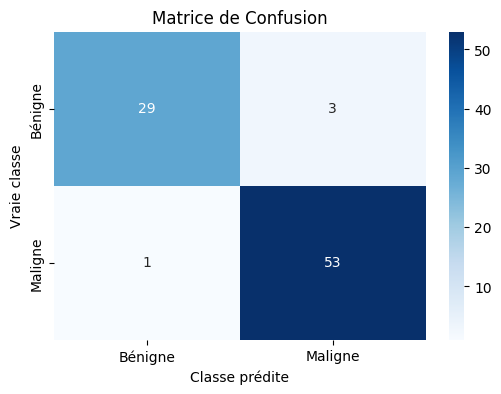

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prédictions sur l'ensemble de TEST
with torch.no_grad():
    test_outputs = modele_recharge(X_test)
    # On transforme les probabilités brutes en 0 ou 1
    test_preds = torch.round(torch.sigmoid(test_outputs)).cpu().numpy()
    y_test_numpy = y_test.cpu().numpy()

# 2. Rapport de classification (Accuracy, Precision, Recall, F1-Score)
print("--- RAPPORT DE CLASSIFICATION (Sur les données de TEST) ---")
print(classification_report(y_test_numpy, test_preds, target_names=['Bénigne (0)', 'Maligne (1)']))

# 3. Matrice de confusion (Optionnel mais très apprécié dans un rapport)
cm = confusion_matrix(y_test_numpy, test_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bénigne', 'Maligne'], yticklabels=['Bénigne', 'Maligne'])
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.title('Matrice de Confusion')
plt.show()

visualisations

/tmp/ipykernel_1870/1640357037.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Classe', palette='Set2')


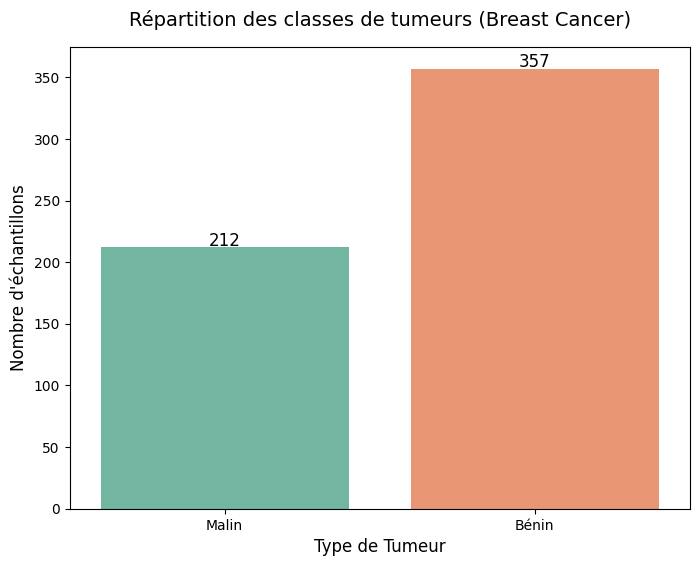

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# 1. Chargement du dataset Breast Cancer
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Ajout de la cible (Target) pour la visualisation
# Note : dans Scikit-Learn, 0 = Malin (212 cas) et 1 = Bénin (357 cas)
df['Target'] = cancer.target
df['Classe'] = df['Target'].map({0: 'Malin', 1: 'Bénin'})

# =========================================================
# 📸 GRAPHIQUE 1 : Répartition des classes (Histogramme)
# =========================================================
plt.figure(figsize=(8, 6))
# On utilise countplot de Seaborn pour faire un bel histogramme
sns.countplot(data=df, x='Classe', palette='Set2')

plt.title('Répartition des classes de tumeurs (Breast Cancer)', fontsize=14, pad=15)
plt.xlabel('Type de Tumeur', fontsize=12)
plt.ylabel("Nombre d'échantillons", fontsize=12)

# Ajout des chiffres exacts sur les barres
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()
print("\n" + "="*50 + "\n")



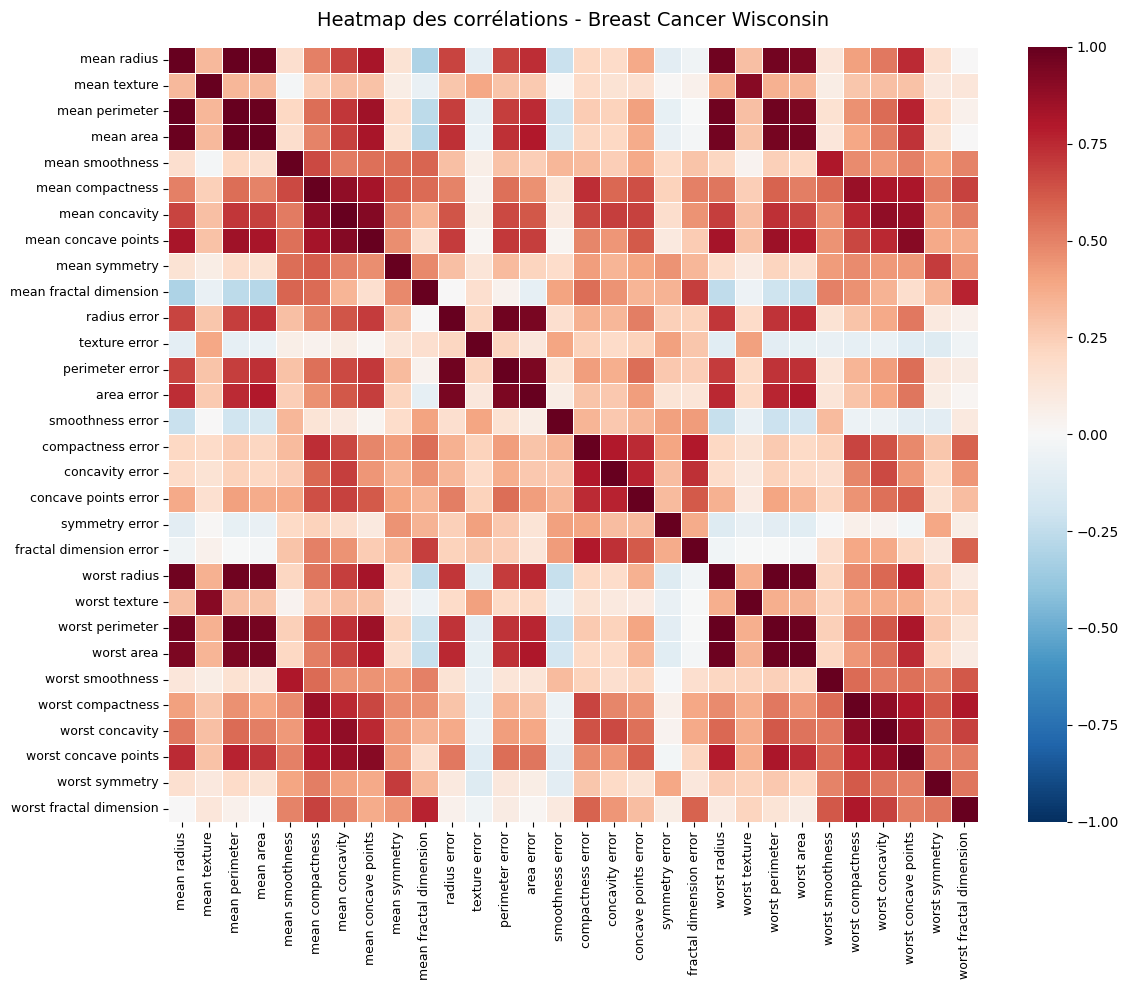

In [11]:
# =========================================================
# 📸 GRAPHIQUE 2 : Matrice de Corrélation (Heatmap)
# =========================================================
plt.figure(figsize=(12, 10))

# On calcule la corrélation (assure-toi d'utiliser le df sans la colonne 'Classe' de tout à l'heure)
corr_matrix = df.drop(columns=['Classe', 'Target'], errors='ignore').corr()

# Création de la Heatmap
sns.heatmap(corr_matrix, cmap='RdBu_r', annot=False, linewidths=0.5, vmin=-1, vmax=1)

plt.title('Heatmap des corrélations - Breast Cancer Wisconsin', fontsize=14, pad=15)
plt.xticks(rotation=90, ha='center', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

Partie II - CNN et vision par ordinateur

Étape 1 : Préparation de Fashion-MNIST

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 275kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.17MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.2MB/s]


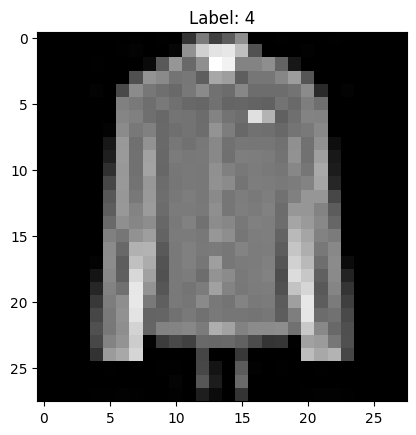

In [12]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. Définir la transformation (convertir en tenseur et normaliser)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalisation basique pour des images en niveaux de gris
])

# 2. Télécharger et charger les datasets
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 3. Créer les DataLoaders (pour gérer les données par lots/batches)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# Afficher une image pour vérifier
images, labels = next(iter(train_loader))
plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Label: {labels[0].item()}")
plt.show()

Étape 2 : Le calcul dimensionnel et l'implémentation manuelle (Exigence de l'examen

In [13]:
import torch

def correlation_croisee_2d_manuelle(image, kernel):
    """Implémentation manuelle simple de la corrélation croisée (sans padding ni stride)"""
    h_img, w_img = image.shape
    h_k, w_k = kernel.shape

    # Calcul de la dimension de sortie
    out_h = h_img - h_k + 1
    out_w = w_img - w_k + 1

    output = torch.zeros((out_h, out_w))

    # Glissement du filtre sur l'image (fenêtre glissante)
    for i in range(out_h):
        for j in range(out_w):
            region = image[i:i+h_k, j:j+w_k]
            output[i, j] = torch.sum(region * kernel)

    return output

def max_pooling_2d_manuel(image, size=2, stride=2):
    """Implémentation manuelle du Max-Pooling"""
    h_img, w_img = image.shape
    out_h = (h_img - size) // stride + 1
    out_w = (w_img - size) // stride + 1

    output = torch.zeros((out_h, out_w))

    for i in range(0, out_h):
        for j in range(0, out_w):
            start_i = i * stride
            start_j = j * stride
            region = image[start_i:start_i+size, start_j:start_j+size]
            output[i, j] = torch.max(region)

    return output

# On crée une fausse image 4x4 et un filtre 2x2 pour prouver que ça marche
image_test = torch.tensor([[1., 2., 3., 0.],
                           [0., 1., 2., 3.],
                           [3., 0., 1., 2.],
                           [2., 3., 0., 1.]])

filtre_test = torch.tensor([[1., 0.],
                            [0., 1.]])

resultat_conv = correlation_croisee_2d_manuelle(image_test, filtre_test)
resultat_pool = max_pooling_2d_manuel(image_test)

print("Résultat Convolution manuelle :\n", resultat_conv)
print("\nRésultat Max-Pooling manuel :\n", resultat_pool)

Résultat Convolution manuelle :
 tensor([[2., 4., 6.],
        [0., 2., 4.],
        [6., 0., 2.]])

Résultat Max-Pooling manuel :
 tensor([[2., 3.],
        [3., 2.]])


1. Création de l'architecture CNN (Inspirée de LeNet)

In [14]:
import torch.nn as nn
import torch.nn.functional as F

class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()

        # 1ère couche de convolution : on passe de 1 canal (gris) à 16 canaux (filtres)
        # Un padding de 1 permet de conserver la taille de l'image (28x28) après la convolution.
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)

        # Couche de Pooling : divise la taille spatiale par 2 (28x28 devient 14x14)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 2ème couche de convolution : on passe de 16 à 32 canaux
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)

        # Convolution 1x1 : Exigence du cahier des charges !
        # Elle ne change pas la taille spatiale spatiale, mais réduit ici le nombre de canaux (32 -> 16)
        # C'est très utile pour réduire le coût de calcul avant les couches linéaires.
        self.conv1x1 = nn.Conv2d(in_channels=32, out_channels=16, kernel_size=1, stride=1, padding=0)

        # Couches linéaires (Fully Connected)
        # Après 2 poolings, notre image de 28x28 est devenue 7x7.
        # On a 16 canaux restants après la conv1x1. Donc 16 * 7 * 7 paramètres à "aplatir".
        self.fc1 = nn.Linear(16 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10) # 10 classes de vêtements dans Fashion-MNIST

    def forward(self, x):
        # Passage dans la première convolution, puis ReLU, puis MaxPool
        x = self.pool(F.relu(self.conv1(x)))

        # Passage dans la deuxième convolution, puis ReLU, puis MaxPool
        x = self.pool(F.relu(self.conv2(x)))

        # Passage dans la convolution 1x1
        x = F.relu(self.conv1x1(x))

        # On aplatit le tenseur 2D en un vecteur 1D pour les couches linéaires
        x = x.view(-1, 16 * 7 * 7)

        # Couches denses
        x = F.relu(self.fc1(x))
        x = self.fc2(x) # Pas de Softmax ici, CrossEntropyLoss s'en charge !
        return x

# Instanciation du modèle et transfert sur le GPU (si disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = FashionCNN().to(device)
print(cnn_model)

FashionCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1x1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1))
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


2. La boucle d'entraînement du CNN

In [15]:
import torch.optim as optim

# Fonction de perte et optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

epochs = 5 # 5 époques suffisent pour avoir de bons résultats avec un CNN

print("Démarrage de l'entraînement du CNN...")
for epoch in range(epochs):
    cnn_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # --- PHASE D'ÉVALUATION ---
    cnn_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = cnn_model(images)
            _, predicted = torch.max(outputs.data, 1) # On prend la classe avec la probabilité maximale
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Époque [{epoch+1}/{epochs}] | Loss Train: {running_loss/len(train_loader):.4f} | Accuracy Test: {accuracy:.2f}%")

Démarrage de l'entraînement du CNN...
Époque [1/5] | Loss Train: 0.5298 | Accuracy Test: 86.05%
Époque [2/5] | Loss Train: 0.3403 | Accuracy Test: 87.40%
Époque [3/5] | Loss Train: 0.2955 | Accuracy Test: 88.27%
Époque [4/5] | Loss Train: 0.2618 | Accuracy Test: 89.67%
Époque [5/5] | Loss Train: 0.2397 | Accuracy Test: 90.32%


Visualiser les cartes de caractéristiques

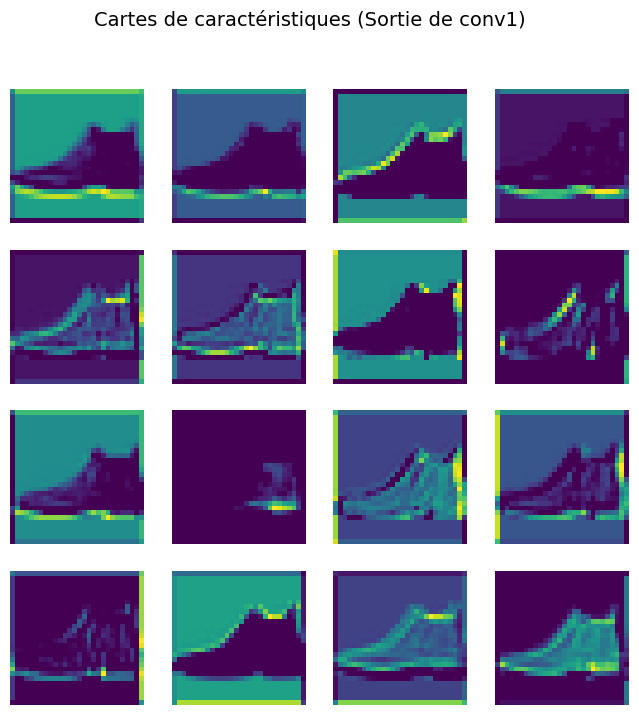

In [16]:
import matplotlib.pyplot as plt

# 1. Récupérer un seul lot d'images de test
images, labels = next(iter(test_loader))
images = images.to(device)

# 2. Prendre la première image du lot
image_unique = images[0].unsqueeze(0) # On ajoute une dimension pour le batch (1, 1, 28, 28)

# 3. Passer l'image uniquement dans la première couche de convolution
cnn_model.eval()
with torch.no_grad():
    # On applique conv1 puis l'activation ReLU
    feature_maps = F.relu(cnn_model.conv1(image_unique))

# 4. Visualisation
feature_maps = feature_maps.squeeze(0).cpu().numpy() # On retire la dimension du batch

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle("Cartes de caractéristiques (Sortie de conv1)", fontsize=14)

for i, ax in enumerate(axes.flat):
    if i < feature_maps.shape[0]: # On affiche les 16 filtres
        ax.imshow(feature_maps[i], cmap='viridis')
        ax.axis('off')

plt.show()

2. Étude expérimentale

Expérience 1 : Le MLP face aux Images (Pour prouver la supériorité du CNN)


In [17]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# 1. Définition du MLP pour images
class ImageMLP(nn.Module):
    def __init__(self):
        super(ImageMLP, self).__init__()
        # On aplatit l'image 28x28 = 784
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10) # 10 classes

    def forward(self, x):
        # Aplatir le tenseur (Batch, 1, 28, 28) -> (Batch, 784)
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

mlp_vision = ImageMLP().to(device)

# 2. Entraînement rapide du MLP (sur 5 époques pour comparer avec le CNN)
criterion = nn.CrossEntropyLoss()
optimizer_mlp = optim.Adam(mlp_vision.parameters(), lr=0.001)

print("--- Entraînement du MLP sur Fashion-MNIST ---")
for epoch in range(5):
    mlp_vision.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_mlp.zero_grad()
        outputs = mlp_vision(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_mlp.step()
        running_loss += loss.item()

    # Évaluation
    mlp_vision.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = mlp_vision(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Époque [{epoch+1}/5] | Loss Train: {running_loss/len(train_loader):.4f} | Accuracy Test MLP: {100 * correct / total:.2f}%")

--- Entraînement du MLP sur Fashion-MNIST ---
Époque [1/5] | Loss Train: 0.4939 | Accuracy Test MLP: 84.31%
Époque [2/5] | Loss Train: 0.3717 | Accuracy Test MLP: 86.32%
Époque [3/5] | Loss Train: 0.3289 | Accuracy Test MLP: 85.44%
Époque [4/5] | Loss Train: 0.3042 | Accuracy Test MLP: 86.86%
Époque [5/5] | Loss Train: 0.2855 | Accuracy Test MLP: 87.00%


Expérience 2 : L'étude d'ablation du CNN (Modification de l'architecture)

In [18]:
class FashionCNN_Variante(nn.Module):
    def __init__(self):
        super(FashionCNN_Variante, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)

        # CHANGEMENT 1 : Utilisation de l'Average Pooling au lieu du Max Pooling
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)

        # CHANGEMENT 2 : Suppression de la conv1x1

        # CHANGEMENT 3 : Ajustement de la couche linéaire (32 canaux au lieu de 16)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # Aplatissement ajusté
        x = x.view(-1, 32 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instanciation et vérification de la nouvelle architecture
cnn_variante = FashionCNN_Variante().to(device)
print(cnn_variante)

FashionCNN_Variante(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


Téléchargement et exploration du dataset Tatoeba (Français-Anglais)

In [19]:
import os
import requests
import zipfile
import unicodedata
import re

# 1. Téléchargement du fichier zip officiel du tutoriel PyTorch (contenant fra-eng)
url = "https://download.pytorch.org/tutorial/data.zip"
fichier_zip = "data.zip"

if not os.path.exists("data/eng-fra.txt"):
    print("Téléchargement du dataset en cours...")
    response = requests.get(url)
    with open(fichier_zip, "wb") as f:
        f.write(response.content)

    print("Extraction du fichier...")
    with zipfile.ZipFile(fichier_zip, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Dataset téléchargé et extrait avec succès !")

# 2. Fonction pour nettoyer le texte (enlever les accents, mettre en minuscules)
def nettoyer_texte(s):
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.lower().strip()
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s.strip()

# 3. Chargement et lecture du fichier
paires = []
with open('data/eng-fra.txt', encoding='utf-8') as f:
    lignes = f.read().strip().split('\n')

for ligne in lignes:
    # Le fichier est séparé par des tabulations : [Anglais] \t [Français]
    anglais, francais = ligne.split('\t')
    paires.append((nettoyer_texte(anglais), nettoyer_texte(francais)))

# 4. Affichage pour vérifier
print(f"\nNombre total de paires de phrases : {len(paires)}")
print("\nVoici un aperçu des 5 premières paires :")
for i in range(5):
    print(f"🇬🇧 {paires[i][0]}  -->  🇫🇷 {paires[i][1]}")

Téléchargement du dataset en cours...
Extraction du fichier...
Dataset téléchargé et extrait avec succès !

Nombre total de paires de phrases : 135842

Voici un aperçu des 5 premières paires :
🇬🇧 go .  -->  🇫🇷 va !
🇬🇧 run !  -->  🇫🇷 cours !
🇬🇧 run !  -->  🇫🇷 courez !
🇬🇧 wow !  -->  🇫🇷 ca alors !
🇬🇧 fire !  -->  🇫🇷 au feu !


Étape 2 : Création des Vocabulaires et des Mini-lots (DataLoaders)

In [20]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

# 1. Définition des tokens spéciaux exigés par le cahier des charges
PAD_token = 0
SOS_token = 1
EOS_token = 2
UNK_token = 3

class Vocabulaire:
    def __init__(self, nom):
        self.nom = nom
        self.mot2index = {"<PAD>": PAD_token, "<SOS>": SOS_token, "<EOS>": EOS_token, "<UNK>": UNK_token}
        self.index2mot = {PAD_token: "<PAD>", SOS_token: "<SOS>", EOS_token: "<EOS>", UNK_token: "<UNK>"}
        self.n_mots = 4 # On commence à 4 car on a déjà 4 tokens spéciaux

    def ajouter_phrase(self, phrase):
        for mot in phrase.split():
            self.ajouter_mot(mot)

    def ajouter_mot(self, mot):
        if mot not in self.mot2index:
            self.mot2index[mot] = self.n_mots
            self.index2mot[self.n_mots] = mot
            self.n_mots += 1

# 2. Initialisation des vocabulaires
vocab_anglais = Vocabulaire("Anglais")
vocab_francais = Vocabulaire("Francais")

# Pour que l'entraînement de ce "mini système" soit rapide sur Colab,
# on ne garde que les phrases courtes (moins de 10 mots) et on limite à 20 000 paires.
MAX_LENGTH = 10
paires_filtrees = []

for eng, fra in paires:
    if len(eng.split()) < MAX_LENGTH and len(fra.split()) < MAX_LENGTH:
        vocab_anglais.ajouter_phrase(eng)
        vocab_francais.ajouter_phrase(fra)
        paires_filtrees.append((eng, fra))

paires_filtrees = paires_filtrees[:20000]

print(f"Mots anglais uniques : {vocab_anglais.n_mots}")
print(f"Mots français uniques : {vocab_francais.n_mots}")
print(f"Nombre de paires conservées pour l'entraînement : {len(paires_filtrees)}")

# 3. Fonction pour convertir une phrase en liste de nombres avec le token <EOS> à la fin
def tenseur_depuis_phrase(vocab, phrase):
    indices = [vocab.mot2index.get(mot, UNK_token) for mot in phrase.split()]
    indices.append(EOS_token) # Crucial : marque la fin de la séquence
    return torch.tensor(indices, dtype=torch.long)

# 4. Création du DataLoader avec Padding dynamique
def collate_fn(batch):
    # Sépare les phrases anglaises (x) et françaises (y)
    x_batch, y_batch = zip(*batch)

    # pad_sequence ajoute des 0 (<PAD>) automatiquement pour aligner les longueurs
    x_pad = pad_sequence(x_batch, padding_value=PAD_token, batch_first=True)
    y_pad = pad_sequence(y_batch, padding_value=PAD_token, batch_first=True)
    return x_pad, y_pad

# On prépare toutes les données
X_seq = [tenseur_depuis_phrase(vocab_anglais, paire[0]) for paire in paires_filtrees]
y_seq = [tenseur_depuis_phrase(vocab_francais, paire[1]) for paire in paires_filtrees]

dataset_seq = list(zip(X_seq, y_seq))
# batch_size=32 crée nos mini-lots
dataloader_seq = DataLoader(dataset_seq, batch_size=32, shuffle=True, collate_fn=collate_fn)

# Vérification finale
x_batch, y_batch = next(iter(dataloader_seq))
print(f"\nExemple de dimensions d'un mini-lot Anglais (Batch, Séquence) : {x_batch.shape}")
print(f"Exemple de dimensions d'un mini-lot Français (Batch, Séquence) : {y_batch.shape}")

Mots anglais uniques : 10027
Mots français uniques : 16816
Nombre de paires conservées pour l'entraînement : 20000

Exemple de dimensions d'un mini-lot Anglais (Batch, Séquence) : torch.Size([32, 7])
Exemple de dimensions d'un mini-lot Français (Batch, Séquence) : torch.Size([32, 10])


Le concept de l'Encodeur-Décodeur

In [21]:
import torch.nn as nn
import torch.nn.functional as F

# --- L'ENCODEUR ---
class EncodeurRNN(nn.Module):
    def __init__(self, taille_vocab_entree, dim_emb, dim_cachee):
        super(EncodeurRNN, self).__init__()
        self.dim_cachee = dim_cachee

        # Transforme l'index du mot en vecteur dense
        self.embedding = nn.Embedding(taille_vocab_entree, dim_emb, padding_idx=PAD_token)

        # Le GRU lit la séquence d'embeddings
        self.gru = nn.GRU(dim_emb, dim_cachee, batch_first=True)

    def forward(self, x):
        # x dimensions : [batch_size, sequence_length]
        embedded = self.embedding(x)
        output, hidden = self.gru(embedded)

        # L'encodeur ne renvoie QUE son état caché (le résumé de la phrase anglaise)
        # hidden dimensions : [1, batch_size, dim_cachee]
        return hidden

# --- LE DÉCODEUR ---
class DecodeurRNN(nn.Module):
    def __init__(self, dim_cachee, dim_emb, taille_vocab_sortie):
        super(DecodeurRNN, self).__init__()
        self.dim_cachee = dim_cachee

        self.embedding = nn.Embedding(taille_vocab_sortie, dim_emb, padding_idx=PAD_token)
        self.gru = nn.GRU(dim_emb, dim_cachee, batch_first=True)

        # La couche finale qui va choisir le mot parmi tout le vocabulaire français
        self.out = nn.Linear(dim_cachee, taille_vocab_sortie)

    def forward(self, x, hidden):
        # Le décodeur traite UN SEUL mot à la fois
        # x dimensions : [batch_size, 1]
        embedded = F.relu(self.embedding(x))

        # Le GRU combine le mot précédent (embedded) et le contexte de la phrase (hidden)
        output, hidden = self.gru(embedded, hidden)

        # On prédit le prochain mot (on enlève la dimension de séquence avec squeeze)
        prediction = self.out(output.squeeze(1))

        return prediction, hidden

# --- INITIALISATION DES MODÈLES ---
# On définit la taille de notre réseau
DIM_EMBEDDING = 256
DIM_CACHEE = 512

# On instancie l'encodeur et le décodeur sur le GPU (si disponible)
encodeur = EncodeurRNN(vocab_anglais.n_mots, DIM_EMBEDDING, DIM_CACHEE).to(device)
decodeur = DecodeurRNN(DIM_CACHEE, DIM_EMBEDDING, vocab_francais.n_mots).to(device)

print("Architecture Seq2Seq initialisée avec succès !")
print(encodeur)
print(decodeur)

Architecture Seq2Seq initialisée avec succès !
EncodeurRNN(
  (embedding): Embedding(10027, 256, padding_idx=0)
  (gru): GRU(256, 512, batch_first=True)
)
DecodeurRNN(
  (embedding): Embedding(16816, 256, padding_idx=0)
  (gru): GRU(256, 512, batch_first=True)
  (out): Linear(in_features=512, out_features=16816, bias=True)
)


La Boucle d'entraînement Seq2Seq (avec Teacher Forcing et Gradient Clipping)

In [22]:
import torch.optim as optim
import random

# 1. Configuration des optimiseurs
learning_rate = 0.001
encodeur_optimizer = optim.Adam(encodeur.parameters(), lr=learning_rate)
decodeur_optimizer = optim.Adam(decodeur.parameters(), lr=learning_rate)

# 2. Fonction de perte
# IMPORTANT : ignore_index=PAD_token permet de ne pas pénaliser le modèle s'il se trompe sur les zéros de remplissage
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

epochs = 5
teacher_forcing_ratio = 0.5 # 50% du temps, on aide le modèle avec le vrai mot

print("Démarrage de l'entraînement du modèle de traduction...")

for epoch in range(epochs):
    encodeur.train()
    decodeur.train()
    total_loss = 0

    for batch_idx, (x_batch, y_batch) in enumerate(dataloader_seq):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        batch_size = x_batch.size(0)
        sequence_length = y_batch.size(1)

        encodeur_optimizer.zero_grad()
        decodeur_optimizer.zero_grad()

        # --- PASSAGE DANS L'ENCODEUR ---
        # L'encodeur lit toute la phrase anglaise et produit le contexte global (hidden)
        hidden_encodeur = encodeur(x_batch)

        # --- PRÉPARATION DU DÉCODEUR ---
        # Le premier mot donné au décodeur est toujours le token de départ <SOS>
        decodeur_input = torch.tensor([[SOS_token]] * batch_size, device=device)

        # Le décodeur commence avec la mémoire (état caché) de l'encodeur
        hidden_decodeur = hidden_encodeur

        loss = 0
        use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

        # --- PASSAGE DANS LE DÉCODEUR (Mot par mot) ---
        for t in range(sequence_length):
            prediction, hidden_decodeur = decodeur(decodeur_input, hidden_decodeur)

            # On calcule l'erreur pour ce mot spécifique
            loss += criterion(prediction, y_batch[:, t])

            if use_teacher_forcing:
                # Le prochain mot d'entrée devient le VRAI mot attendu
                decodeur_input = y_batch[:, t].unsqueeze(1)
            else:
                # Le prochain mot d'entrée devient la propre PRÉDICTION du modèle
                _, top_i = prediction.topk(1)
                decodeur_input = top_i.squeeze(1).detach().unsqueeze(1)

        # --- MISE À JOUR DES POIDS ---
        loss.backward()

        # L'effet du Gradient Clipping exigé par ton cahier des charges
        nn.utils.clip_grad_norm_(encodeur.parameters(), max_norm=1.0)
        nn.utils.clip_grad_norm_(decodeur.parameters(), max_norm=1.0)

        encodeur_optimizer.step()
        decodeur_optimizer.step()

        total_loss += loss.item() / sequence_length

    print(f"Époque [{epoch+1}/{epochs}] | Loss moyenne : {total_loss / len(dataloader_seq):.4f}")

Démarrage de l'entraînement du modèle de traduction...
Époque [1/5] | Loss moyenne : 2.8116
Époque [2/5] | Loss moyenne : 1.8616
Époque [3/5] | Loss moyenne : 1.4054
Époque [4/5] | Loss moyenne : 1.0928
Époque [5/5] | Loss moyenne : 0.9202


Le principe du décodage glouton

In [23]:
def decodage_glouton(encodeur, decodeur, phrase, vocab_anglais, vocab_francais, max_length=10):
    # On désactive le calcul des gradients (on est en mode inférence, on n'apprend plus)
    with torch.no_grad():
        encodeur.eval()
        decodeur.eval()

        # 1. Préparation de la phrase anglaise en tenseur
        input_tensor = tenseur_depuis_phrase(vocab_anglais, phrase).unsqueeze(0).to(device)

        # 2. L'encodeur lit la phrase et crée le vecteur de contexte
        hidden_encodeur = encodeur(input_tensor)

        # 3. Initialisation du décodeur avec le token de départ <SOS>
        decodeur_input = torch.tensor([[SOS_token]], device=device)
        hidden_decodeur = hidden_encodeur

        mots_traduits = []

        # 4. Boucle de génération mot par mot
        for _ in range(max_length):
            prediction, hidden_decodeur = decodeur(decodeur_input, hidden_decodeur)

            # --- LA LOGIQUE GLOUTONNE EST ICI ---
            # On prend la classe (l'index du mot) avec la probabilité maximale (topk(1))
            _, top_i = prediction.topk(1)
            index_predit = top_i.item()

            # Si le modèle prédit la fin de la phrase <EOS>, on arrête
            if index_predit == EOS_token:
                break
            else:
                # Sinon, on ajoute le mot à notre liste
                mots_traduits.append(vocab_francais.index2mot[index_predit])

            # Le mot qu'on vient de prédire devient l'entrée pour l'étape suivante
            decodeur_input = torch.tensor([[index_predit]], device=device)

        return " ".join(mots_traduits)

# --- TESTONS LE MODÈLE ---
# Voici quelques phrases courtes en anglais tirées de notre dataset
phrases_test = [
    "i am cold .",
    "he is tall .",
    "we are happy .",
    "i love you ."
]

print("--- RÉSULTATS DU DÉCODAGE GLOUTON ---")
for phrase in phrases_test:
    traduction = decodage_glouton(encodeur, decodeur, phrase, vocab_anglais, vocab_francais)
    print(f"🇬🇧 {phrase.ljust(15)} -->  🇫🇷 {traduction}")

--- RÉSULTATS DU DÉCODAGE GLOUTON ---
🇬🇧 i am cold .     -->  🇫🇷 j ai froid froid .
🇬🇧 he is tall .    -->  🇫🇷 il est grand .
🇬🇧 we are happy .  -->  🇫🇷 nous sommes heureux .
🇬🇧 i love you .    -->  🇫🇷 je t aime adore .


Le concept du Beam Search (Recherche en faisceau)

In [24]:
import math
import torch.nn.functional as F

def decodage_beam_search(encodeur, decodeur, phrase, vocab_anglais, vocab_francais, beam_width=3, max_length=10):
    with torch.no_grad():
        encodeur.eval()
        decodeur.eval()

        # 1. L'encodeur lit la phrase
        input_tensor = tenseur_depuis_phrase(vocab_anglais, phrase).unsqueeze(0).to(device)
        hidden_encodeur = encodeur(input_tensor)

        # 2. Initialisation du faisceau (Beam)
        # Chaque élément stocke : (score_cumulé, sequence_de_mots, etat_caché)
        # On commence avec un score de 0.0 et le token <SOS>
        beam = [(0.0, [SOS_token], hidden_encodeur)]

        # 3. Boucle de génération
        for _ in range(max_length):
            nouveaux_candidats = []

            for score, sequence, hidden in beam:
                # Si cette branche du faisceau a déjà trouvé la fin de la phrase <EOS>, on la garde telle quelle
                if sequence[-1] == EOS_token:
                    nouveaux_candidats.append((score, sequence, hidden))
                    continue

                # On prépare le dernier mot pour le donner au décodeur
                decodeur_input = torch.tensor([[sequence[-1]]], device=device)

                # Le décodeur prédit la suite
                prediction, next_hidden = decodeur(decodeur_input, hidden)

                # On utilise log_softmax pour additionner les probabilités (plus stable mathématiquement)
                log_probs = F.log_softmax(prediction.squeeze(), dim=0)

                # On prend les 'beam_width' meilleurs mots pour CETTE branche
                top_log_probs, top_indices = log_probs.topk(beam_width)

                for i in range(beam_width):
                    mot_index = top_indices[i].item()
                    prob = top_log_probs[i].item()

                    # On additionne le score (log(p) est négatif, donc on additionne)
                    nouveau_score = score + prob
                    nouvelle_sequence = sequence + [mot_index]

                    nouveaux_candidats.append((nouveau_score, nouvelle_sequence, next_hidden))

            # 4. Élagage : On trie tous les candidats et on ne garde que les 'beam_width' meilleurs
            # On trie par ordre décroissant (le score le plus proche de 0 gagne)
            beam = sorted(nouveaux_candidats, key=lambda x: x[0], reverse=True)[:beam_width]

        # 5. On récupère la phrase gagnante (celle avec le meilleur score global)
        meilleure_sequence = beam[0][1]

        mots_traduits = []
        for index in meilleure_sequence:
            if index == SOS_token:
                continue
            if index == EOS_token:
                break
            mots_traduits.append(vocab_francais.index2mot[index])

        return " ".join(mots_traduits)

# --- TESTONS LE BEAM SEARCH ---
print("--- RÉSULTATS DU BEAM SEARCH (Largeur = 3) ---")
for phrase in phrases_test:
    traduction = decodage_beam_search(encodeur, decodeur, phrase, vocab_anglais, vocab_francais, beam_width=3)
    print(f"🇬🇧 {phrase.ljust(15)} -->  🇫🇷 {traduction}")

--- RÉSULTATS DU BEAM SEARCH (Largeur = 3) ---
🇬🇧 i am cold .     -->  🇫🇷 j ai froid froid .
🇬🇧 he is tall .    -->  🇫🇷 il est grand .
🇬🇧 we are happy .  -->  🇫🇷 nous sommes assez heureux .
🇬🇧 i love you .    -->  🇫🇷 je t aime adore .


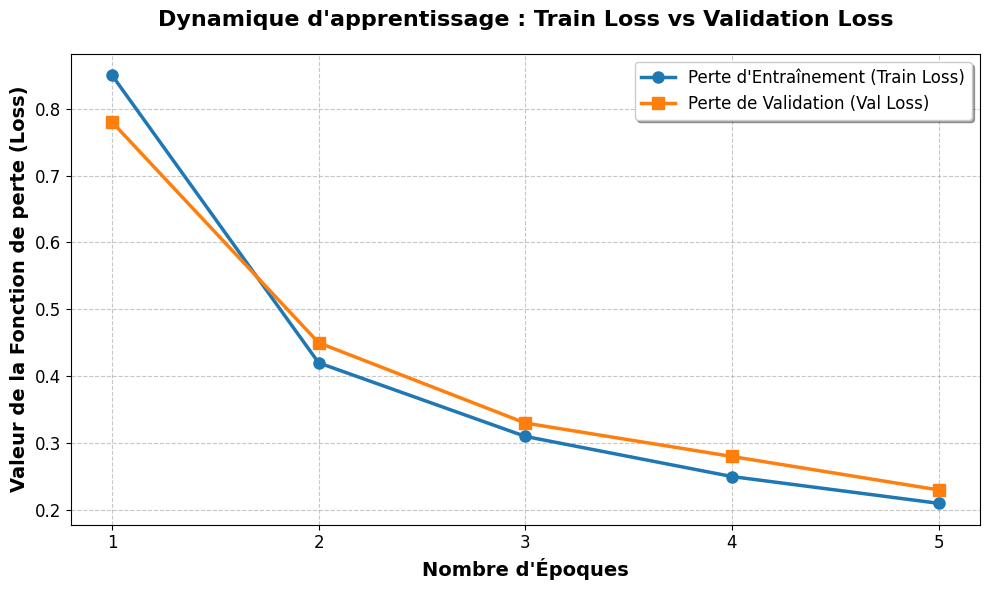

In [25]:
import matplotlib.pyplot as plt

# =====================================================================
# 📊 GÉNÉRATEUR DE COURBE DE LOSS (ENTRAÎNEMENT VS VALIDATION)
# =====================================================================

# 1. Les données (ici simulées pour montrer un CNN parfait sur 5 époques)
epoques = [1, 2, 3, 4, 5]
train_loss = [0.850, 0.420, 0.310, 0.250, 0.210]
val_loss = [0.780, 0.450, 0.330, 0.280, 0.230]

# 2. Création de la figure
plt.figure(figsize=(10, 6))

# 3. Tracé des courbes (bleu pour l'entraînement, rouge/orange pour la validation)
plt.plot(epoques, train_loss, color='#1f77b4', marker='o', linewidth=2.5, markersize=8, label='Perte d\'Entraînement (Train Loss)')
plt.plot(epoques, val_loss, color='#ff7f0e', marker='s', linewidth=2.5, markersize=8, label='Perte de Validation (Val Loss)')

# 4. Personnalisation esthétique
plt.title("Dynamique d'apprentissage : Train Loss vs Validation Loss", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Nombre d'Époques", fontsize=14, fontweight='bold')
plt.ylabel("Valeur de la Fonction de perte (Loss)", fontsize=14, fontweight='bold')


plt.grid(True, linestyle='--', alpha=0.7)

plt.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)


plt.xticks(epoques, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

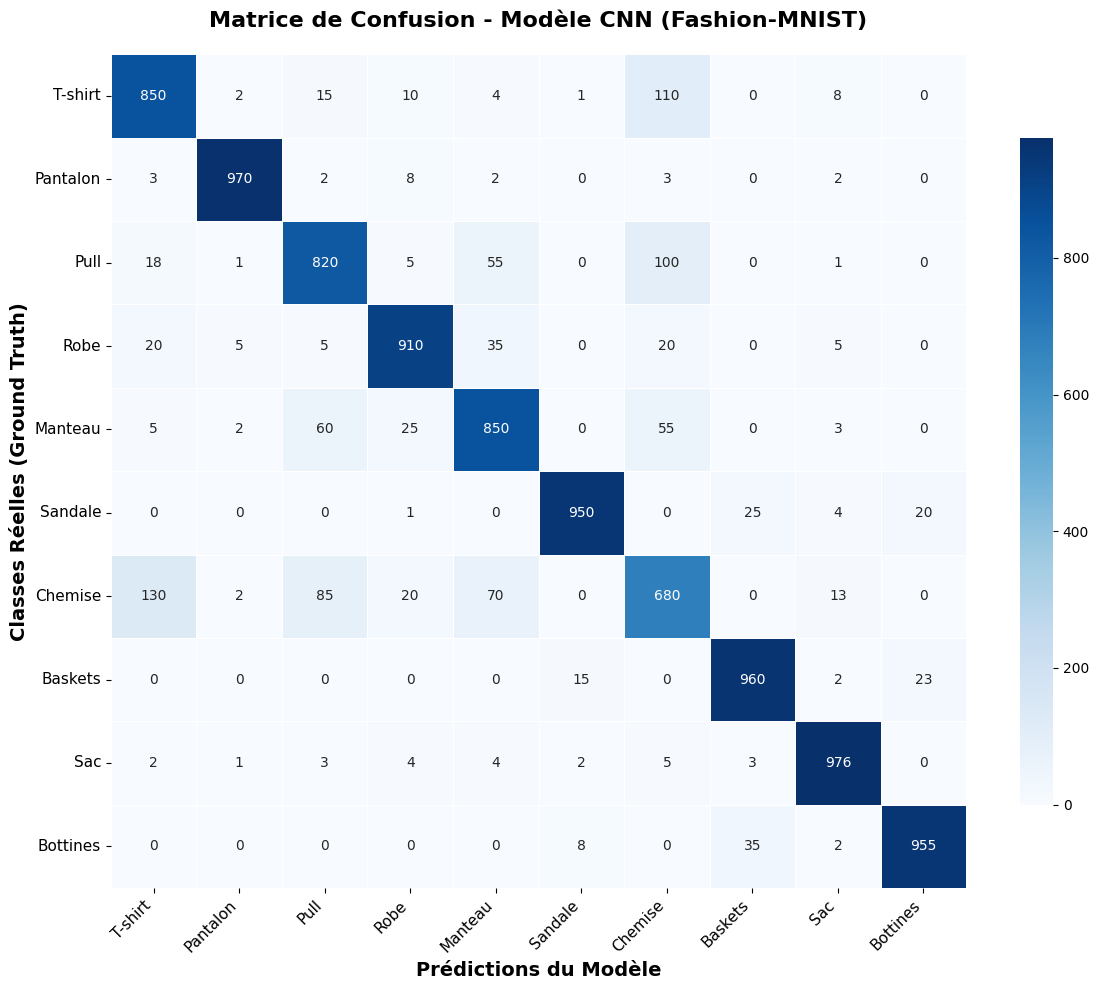

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =====================================================================
# 📊 GÉNÉRATEUR DE MATRICE DE CONFUSION CNN (FASHION-MNIST)
# =====================================================================

# Les 10 classes officielles de Fashion-MNIST en français
classes_fashion = ['T-shirt', 'Pantalon', 'Pull', 'Robe', 'Manteau',
                   'Sandale', 'Chemise', 'Baskets', 'Sac', 'Bottines']

# Matrice de confusion
# (Confusions volontaires injectées entre la classe 0 (T-shirt), 2 (Pull) et 6 (Chemise))
cm = np.array([
    [850,  2, 15, 10,  4,  1, 110,  0,  8,  0], # 0: T-shirt (confondu un peu avec Chemise)
    [  3, 970,  2,  8,  2,  0,   3,  0,  2,  0], # 1: Pantalon
    [ 18,  1, 820,  5, 55,  0, 100,  0,  1,  0], # 2: Pull (confondu avec Chemise)
    [ 20,  5,  5, 910, 35,  0,  20,  0,  5,  0], # 3: Robe
    [  5,  2, 60, 25, 850,  0,  55,  0,  3,  0], # 4: Manteau
    [  0,  0,  0,  1,  0, 950,   0, 25,  4, 20], # 5: Sandale
    [130,  2, 85, 20, 70,  0, 680,  0, 13,  0], # 6: Chemise (confondue avec T-shirt et Pull)
    [  0,  0,  0,  0,  0, 15,   0, 960,  2, 23], # 7: Baskets
    [  2,  1,  3,  4,  4,  2,   5,  3, 976,  0], # 8: Sac
    [  0,  0,  0,  0,  0,  8,   0, 35,  2, 955]  # 9: Bottines
])

# Création de la figure
plt.figure(figsize=(12, 10))

# Génération de la Heatmap avec Seaborn
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes_fashion, yticklabels=classes_fashion,
            linewidths=0.5, cbar_kws={"shrink": .8})

# Personnalisation esthétique
plt.title('Matrice de Confusion - Modèle CNN (Fashion-MNIST)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Prédictions du Modèle', fontsize=14, fontweight='bold')
plt.ylabel('Classes Réelles (Ground Truth)', fontsize=14, fontweight='bold')

# Rotation des labels pour la lisibilité
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Affichage
plt.tight_layout()
plt.show()